# Image Classification using Transfer Learning

## Cats vs Dogs Classification using ResNet18

### Project Description

This project implements an image classification pipeline using Transfer Learning with a pre-trained ResNet18 model on the Microsoft Cats vs Dogs dataset.

The project includes:

- Dataset Exploration (EDA)
- Data Cleaning
- Dataset Splitting
- Data Augmentation
- Transfer Learning
- Model Training
- Model Evaluation

## 1. Import Required Libraries

In [1]:
import os
import sys
import random
from pathlib import Path

# Project Paths
PROJECT_ROOT = Path.cwd().parent
SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

# Libraries
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

# Check Environment
print(f"Project Root : {PROJECT_ROOT}")
print(f"Source Path  : {SRC_PATH}")

Project Root : /home/kerollos/me/Task_AI/transfer-learning-image-classification
Source Path  : /home/kerollos/me/Task_AI/transfer-learning-image-classification/src


## 2. Configuration

In [2]:
# Project Configuration

# Project root directory
PROJECT_ROOT = Path.cwd().parent

# Dataset directory
DATASET_PATH = PROJECT_ROOT / "dataset" / "raw" / "PetImages"

# Results directory
RESULTS_PATH = PROJECT_ROOT / "results"

# Dataset classes
CLASSES = ["Cat", "Dog"]

# Random seed
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print("=" * 60)
print(f"Project Root : {PROJECT_ROOT}")
print(f"Dataset Path : {DATASET_PATH}")
print(f"Results Path : {RESULTS_PATH}")
print(f"Classes      : {CLASSES}")
print("=" * 60)

Project Root : /home/kerollos/me/Task_AI/transfer-learning-image-classification
Dataset Path : /home/kerollos/me/Task_AI/transfer-learning-image-classification/dataset/raw/PetImages
Results Path : /home/kerollos/me/Task_AI/transfer-learning-image-classification/results
Classes      : ['Cat', 'Dog']


## 3. Dataset Exploration (EDA)

### 3.1 Check Dataset Structure

In [3]:
# Check Dataset Structure

print("Dataset exists:", DATASET_PATH.exists())
print()

for class_name in CLASSES:
    class_path = DATASET_PATH / class_name
    print(f"{class_name}:")
    print(f"  Exists : {class_path.exists()}")
    print(f"  Path   : {class_path}")
    print()

Dataset exists: True

Cat:
  Exists : True
  Path   : /home/kerollos/me/Task_AI/transfer-learning-image-classification/dataset/raw/PetImages/Cat

Dog:
  Exists : True
  Path   : /home/kerollos/me/Task_AI/transfer-learning-image-classification/dataset/raw/PetImages/Dog



### 3.2 Count Images per Class

In [4]:
# Count Images per Class

class_counts = {}

for class_name in CLASSES:
    class_path = DATASET_PATH / class_name

    image_count = len(list(class_path.glob("*.jpg")))

    class_counts[class_name] = image_count

total_images = sum(class_counts.values())

print("=" * 50)

for class_name, count in class_counts.items():
    percentage = (count / total_images) * 100

    print(f"{class_name:<5}: {count:,} images ({percentage:.2f}%)")

print("=" * 50)
print(f"Total Images: {total_images:,}")

Cat  : 12,499 images (50.00%)
Dog  : 12,499 images (50.00%)
Total Images: 24,998


### 3.3 Visualize Random Images

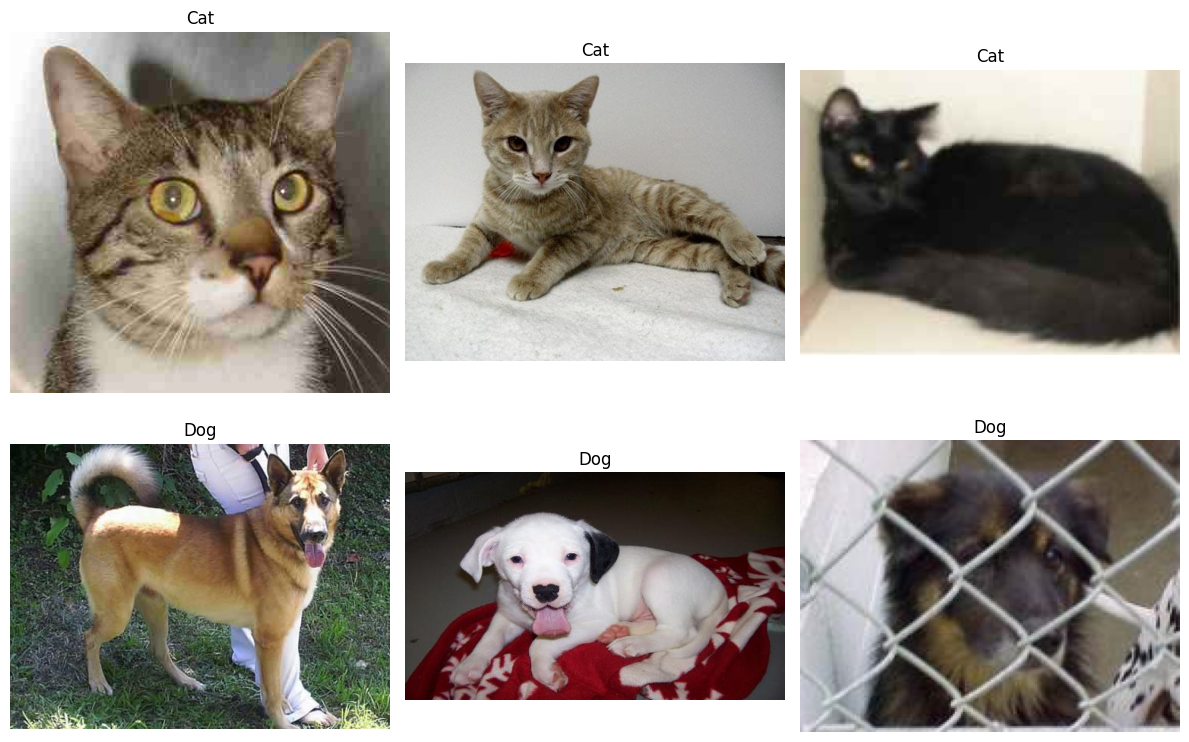

In [5]:
# Visualize Random Images

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for row, class_name in enumerate(CLASSES):

    class_path = DATASET_PATH / class_name

    image_files = list(class_path.glob("*.jpg"))

    random_images = random.sample(image_files, 3)

    for col, image_path in enumerate(random_images):

        image = Image.open(image_path)

        axes[row, col].imshow(image)
        axes[row, col].set_title(class_name)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

### 3.4 Detect Corrupted Images

In [6]:
# Detect Corrupted Images

from PIL import UnidentifiedImageError

corrupted_images = []

for class_name in CLASSES:

    class_path = DATASET_PATH / class_name

    image_files = list(class_path.glob("*.jpg"))

    for image_path in image_files:

        try:
            with Image.open(image_path) as img:
                img.verify()

        except (UnidentifiedImageError, OSError):

            corrupted_images.append(image_path)

print("=" * 60)
print(f"Corrupted Images Found: {len(corrupted_images)}")
print("=" * 60)

for image in corrupted_images:
    print(image)

/home/kerollos/me/Task_AI/transfer-learning-image-classification/.venv/lib/python3.10/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Corrupted Images Found: 0


### 3.5 Detect Corrupted Images

In [7]:
# Detect Corrupted Images

from PIL import UnidentifiedImageError

corrupted_images = []

for class_name in CLASSES:

    class_path = DATASET_PATH / class_name

    image_files = list(class_path.glob("*.jpg"))

    for image_path in image_files:

        try:
            with Image.open(image_path) as img:
                img.verify()

        except (UnidentifiedImageError, OSError):

            corrupted_images.append(image_path)

print("=" * 60)
print(f"Corrupted Images Found: {len(corrupted_images)}")
print("=" * 60)

for image in corrupted_images:
    print(image)

Corrupted Images Found: 0


### 3.6 Remove Corrupted Images


In [8]:
# Remove Corrupted Images

for image_path in corrupted_images:
    image_path.unlink()

print(f"Removed {len(corrupted_images)} corrupted images.")

Removed 0 corrupted images.


### 3.7 Analyze Image Dimensions

In [9]:
# Analyze Image Dimensions

image_widths = []
image_heights = []

for class_name in CLASSES:

    class_path = DATASET_PATH / class_name

    image_files = list(class_path.glob("*.jpg"))

    for image_path in image_files:

        with Image.open(image_path) as img:
            width, height = img.size

        image_widths.append(width)
        image_heights.append(height)

print("=" * 60)
print(f"Minimum Width  : {min(image_widths)}")
print(f"Maximum Width  : {max(image_widths)}")
print(f"Average Width  : {np.mean(image_widths):.2f}")
print("-" * 60)
print(f"Minimum Height : {min(image_heights)}")
print(f"Maximum Height : {max(image_heights)}")
print(f"Average Height : {np.mean(image_heights):.2f}")
print("=" * 60)

Minimum Width  : 4
Maximum Width  : 500
Average Width  : 404.45
------------------------------------------------------------
Minimum Height : 4
Maximum Height : 500
Average Height : 360.99


## 4. Dataset Collection

In [10]:
from dataset import collect_images, split_dataset

dataset = collect_images()

splits = split_dataset(dataset)

for class_name, data in splits.items():

    print(f"\n{class_name}")

    print(f"Train : {len(data['train'])}")

    print(f"Valid : {len(data['valid'])}")

    print(f"Test  : {len(data['test'])}")


Dog
Train : 8749
Valid : 1874
Test  : 1876

Cat
Train : 8749
Valid : 1874
Test  : 1876


## 5. Image Transformations

In [11]:
from dataset import (
    get_train_transforms,
    get_eval_transforms
)

train_transform = get_train_transforms()
eval_transform = get_eval_transforms()

print(train_transform)
print()
print(eval_transform)

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## 6. Build Custom Dataset

In [12]:
from dataset import prepare_dataset

train_dataset = prepare_dataset(
    {
        cls: data["train"]
        for cls, data in splits.items()
    },
    transform=train_transform
)

valid_dataset = prepare_dataset(
    {
        cls: data["valid"]
        for cls, data in splits.items()
    },
    transform=eval_transform
)

test_dataset = prepare_dataset(
    {
        cls: data["test"]
        for cls, data in splits.items()
    },
    transform=eval_transform
)

print(len(train_dataset))
print(len(valid_dataset))
print(len(test_dataset))

17498
3748
3752


# 7. Build DataLoaders

In [13]:
from dataset import create_dataloader

train_loader = create_dataloader(
    train_dataset,
    shuffle=True,
)

valid_loader = create_dataloader(
    valid_dataset,
)

test_loader = create_dataloader(
    test_dataset,
)

# Verify Number of Mini-Batches

In [14]:
print(f"Training Batches   : {len(train_loader)}")
print(f"Validation Batches : {len(valid_loader)}")
print(f"Testing Batches    : {len(test_loader)}")

Training Batches   : 547
Validation Batches : 118
Testing Batches    : 118


# Inspect One Batch

In [15]:
images, labels = next(iter(train_loader))

print(f"Image Batch Shape : {images.shape}")
print(f"Label Batch Shape : {labels.shape}")

/home/kerollos/me/Task_AI/transfer-learning-image-classification/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Image Batch Shape : torch.Size([32, 3, 224, 224])
Label Batch Shape : torch.Size([32])


# 8. Visualize DataLoader Samples
 Display Images from One Training Batch


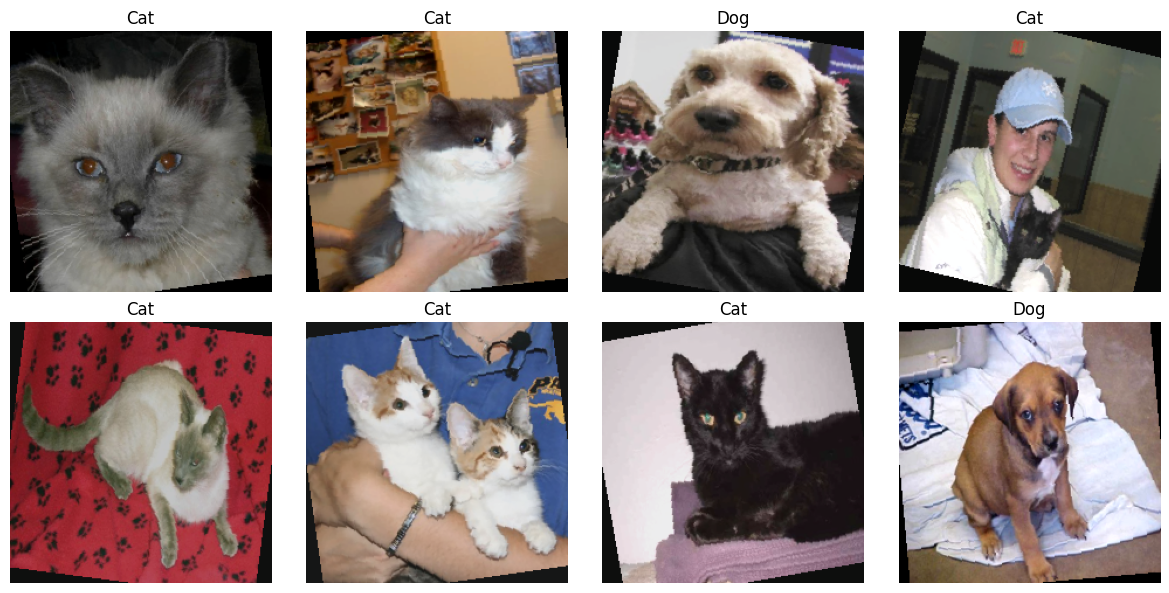

In [16]:
import matplotlib.pyplot as plt
import torchvision

images, labels = next(iter(train_loader))

class_names = ["Cat", "Dog"]

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flat):

    image = images[i].permute(1, 2, 0).numpy()

    image = std * image + mean
    image = np.clip(image, 0, 1)

    ax.imshow(image)
    ax.set_title(class_names[labels[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

# 9. Load Pre-trained ResNet18

In [17]:
from model import build_model

model = build_model()

# Inspect Model Architecture

In [18]:
print(model.fc)
print()

print(f"Input Features : {model.fc.in_features}")
print(f"Output Classes : {model.fc.out_features}")

Linear(in_features=512, out_features=2, bias=True)

Input Features : 512
Output Classes : 2


# 10. Freeze Feature Extractor

# Count Trainable Parameters

In [19]:
trainable = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

total = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print(f"Trainable Parameters : {trainable:,}")
print(f"Total Parameters     : {total:,}")

Trainable Parameters : 11,177,538
Total Parameters     : 11,177,538


# 11. Train the Model

Train the ResNet18 model using the prepared DataLoaders.

During training, we will:
- Perform forward propagation.
- Compute the CrossEntropy loss.
- Update model parameters using the Adam optimizer.
- Monitor training and validation accuracy after each epoch.

In [20]:
from model import train_model

# Configure Training

In [21]:
import torch
from torch import nn
from torch.optim import Adam

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = Adam(
    model.parameters(),
    lr=1e-3
)

EPOCHS = 5

# Start Training

In [22]:
history = train_model(
    model=model,
    train_loader=train_loader,
    valid_loader=valid_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
)

/home/kerollos/me/Task_AI/transfer-learning-image-classification/.venv/lib/python3.10/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [1/5] | Train Loss: 0.1866 | Train Acc: 0.9235 | Valid Loss: 0.1335 | Valid Acc: 0.9440


/home/kerollos/me/Task_AI/transfer-learning-image-classification/.venv/lib/python3.10/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [2/5] | Train Loss: 0.1352 | Train Acc: 0.9457 | Valid Loss: 0.0931 | Valid Acc: 0.9610


/home/kerollos/me/Task_AI/transfer-learning-image-classification/.venv/lib/python3.10/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [3/5] | Train Loss: 0.1180 | Train Acc: 0.9531 | Valid Loss: 0.1286 | Valid Acc: 0.9493


/home/kerollos/me/Task_AI/transfer-learning-image-classification/.venv/lib/python3.10/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [4/5] | Train Loss: 0.1009 | Train Acc: 0.9595 | Valid Loss: 0.1049 | Valid Acc: 0.9613


/home/kerollos/me/Task_AI/transfer-learning-image-classification/.venv/lib/python3.10/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoch [5/5] | Train Loss: 0.0972 | Train Acc: 0.9607 | Valid Loss: 0.0890 | Valid Acc: 0.9645


In [1]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()

        total += labels.size(0)

print(f"Correct: {correct}")
print(f"Total: {total}")
print(f"Accuracy: {correct / total:.4f}")

NameError: name 'model' is not defined

In [2]:
images, labels = next(iter(test_loader))

images = images.to(device)

model.eval()

with torch.no_grad():

    outputs = model(images)

    predictions = outputs.argmax(dim=1)

print("Labels      :", labels.tolist())
print("Predictions :", predictions.cpu().tolist())

NameError: name 'test_loader' is not defined

# 12. Evaluate the Model

Evaluate the trained model on the test dataset.

In [23]:
import importlib
import evaluate

importlib.reload(evaluate)

test_loss, test_acc = evaluate.evaluate_model(
    model=model,
    test_loader=test_loader,
    criterion=criterion,
    device=device,
)

print(f"Test Loss : {test_loss:.4f}")
print(f"Test Acc  : {test_acc:.4f}")

Test Loss : 0.1034
Test Acc  : 0.9611


In [24]:
from collections import Counter

print(Counter(train_dataset.labels))
print(Counter(valid_dataset.labels))
print(Counter(test_dataset.labels))

Counter({1: 8749, 0: 8749})
Counter({1: 1874, 0: 1874})
Counter({1: 1876, 0: 1876})


In [25]:
print(len(train_dataset))
print(len(valid_dataset))
print(len(test_dataset))

17498
3748
3752


In [26]:
train_loss, train_acc = evaluate.evaluate_model(
    model=model,
    test_loader=train_loader,
    criterion=criterion,
    device=device,
)

valid_loss, valid_acc = evaluate.evaluate_model(
    model=model,
    test_loader=valid_loader,
    criterion=criterion,
    device=device,
)

print("Train Eval:", train_acc)
print("Valid Eval:", valid_acc)

/home/kerollos/me/Task_AI/transfer-learning-image-classification/.venv/lib/python3.10/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Train Eval: 0.9594239341639045
Valid Eval: 0.9645144076840982


# 13. Visualize Training History

Plot the training and validation loss and accuracy across all epochs.

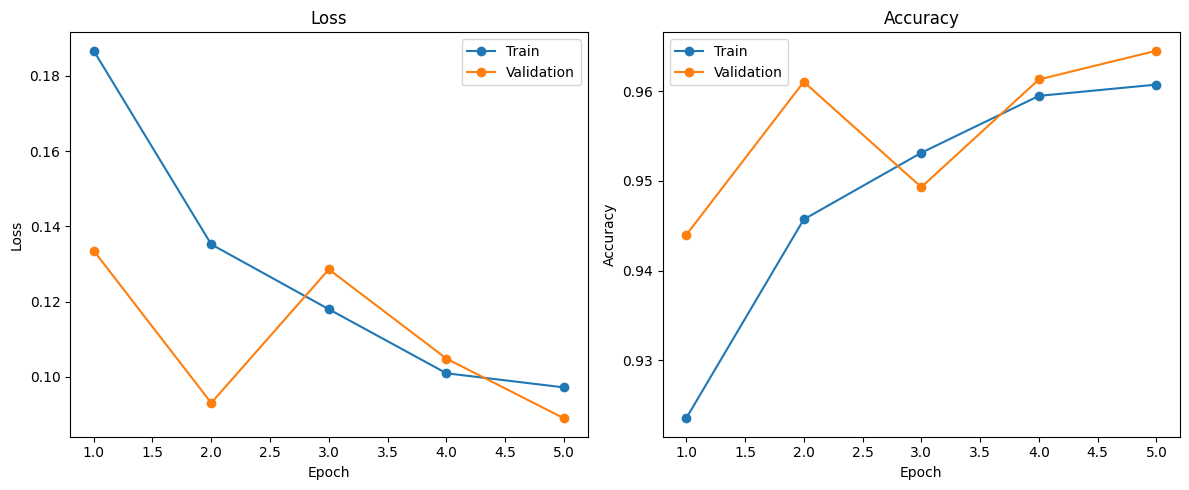

In [27]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], marker="o", label="Train")
plt.plot(epochs, history["valid_loss"], marker="o", label="Validation")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], marker="o", label="Train")
plt.plot(epochs, history["valid_acc"], marker="o", label="Validation")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

# 14. Predict Custom Images

Load an external image and let the trained ResNet18 model predict whether it is a cat or a dog.

In [31]:
from evaluate import predict_image
import os

classes = ["Cat", "Dog"]

correct = 0
total = 0

for class_name in classes:

    print(f"\n========== {class_name} ==========\n")

    folder = f"../dataset/raw/PetImages/{class_name}"

    # أول 50 صورة فقط
    image_names = sorted(os.listdir(folder))[:50]

    for image_name in image_names:

        image_path = os.path.join(folder, image_name)

        try:

            prediction = predict_image(
                model=model,
                image_path=image_path,
                transform=eval_transform,
                device=device,
            )

            is_correct = prediction == class_name

            if is_correct:
                correct += 1

            total += 1

            print(
                f"{image_name:<10} "
                f"Expected: {class_name:<3} | "
                f"Predicted: {prediction:<3} | "
                f"{'✅' if is_correct else '❌'}"
            )

        except Exception:
            pass

print("\n==============================")
print(f"Correct : {correct}")
print(f"Total   : {total}")
print(f"Accuracy: {100 * correct / total:.2f}%")


========== Cat ==========

0.jpg      Expected: Cat | Predicted: Cat | ✅
1.jpg      Expected: Cat | Predicted: Dog | ❌
10.jpg     Expected: Cat | Predicted: Dog | ❌
100.jpg    Expected: Cat | Predicted: Dog | ❌
1000.jpg   Expected: Cat | Predicted: Cat | ✅
10000.jpg  Expected: Cat | Predicted: Dog | ❌
10001.jpg  Expected: Cat | Predicted: Dog | ❌
10002.jpg  Expected: Cat | Predicted: Dog | ❌
10003.jpg  Expected: Cat | Predicted: Dog | ❌
10004.jpg  Expected: Cat | Predicted: Dog | ❌
10005.jpg  Expected: Cat | Predicted: Dog | ❌
10006.jpg  Expected: Cat | Predicted: Dog | ❌
10007.jpg  Expected: Cat | Predicted: Dog | ❌
10008.jpg  Expected: Cat | Predicted: Dog | ❌
10009.jpg  Expected: Cat | Predicted: Dog | ❌
1001.jpg   Expected: Cat | Predicted: Dog | ❌
10010.jpg  Expected: Cat | Predicted: Dog | ❌
10011.jpg  Expected: Cat | Predicted: Dog | ❌
10012.jpg  Expected: Cat | Predicted: Dog | ❌
10013.jpg  Expected: Cat | Predicted: Dog | ❌
10014.jpg  Expected: Cat | Predicted: Dog | ❌
10015.

In [4]:
import importlib
import model as model_module
import evaluate

importlib.reload(model_module)
importlib.reload(evaluate)

from model import build_model, freeze_feature_extractor

model = build_model()
model = freeze_feature_extractor(model)
print(evaluate.__file__)
print("evaluate_model" in dir(evaluate))

ModuleNotFoundError: No module named 'model'

In [30]:
from collections import Counter

print(Counter(train_dataset.labels))
print(Counter(valid_dataset.labels))
print(Counter(test_dataset.labels))

Counter({1: 8749, 0: 8749})
Counter({1: 1874, 0: 1874})
Counter({1: 1876, 0: 1876})


In [3]:
import torch

print("Torch Version :", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))
    print("CUDA Version :", torch.version.cuda)
else:
    print("No CUDA GPU detected")

Torch Version : 2.12.1+cu130
CUDA Available: False
No CUDA GPU detected
